# 2.4.2 稳定性与非负性不是一回事

## 学习目标与先修知识

能推导欧拉法（forward Euler method）偏差放大因子，分别判断渐近稳定（asymptotic stability）、非负性（nonnegativity）和精度，保留并解释数值负值与振荡。

先修：上一节的误差与递推，第 2.3 章的平衡（equilibrium）解。 [复习上一节](01-误差与网格细化.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

无输入（input）清除本应一直保持正所追踪物质总量（tracked amount）。为何某条数值曲线变成 10、−5、2.5、−1.25…，明明还在趋近零？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
value=10.0;values=[value]
for _ in range(5):
    value+=2*(0-.75*value)
    values.append(value)
display(Markdown(show_table(['更新次数','欧拉总量 / U'],enumerate(values))))

| 更新次数 | 欧拉总量 / U |
| --- | --- |
| 0 | 10 |
| 1 | -5 |
| 2 | 2.5 |
| 3 | -1.25 |
| 4 | 0.625 |
| 5 | -0.3125 |

## 模型假设

对 k≥0、u≥0、A0≥0 的恒定输入一阶模型（model），采用固定步长的显式欧拉法（forward Euler method）。模型是线性的，因此下面的偏差递推对任意初始偏差都精确成立。

## 数学解释与推导

在 k>0 情况下令 $e_n=A_n-A^*$。减去平衡关系，得到
$$e_{n+1}=(1-kh)e_n=q e_n.$$
所以 $e_n=q^n e_0$。任意初始偏离都趋近零，当且仅当 $|q|<1$，即 $0<kh<2$。当 kh=2，q=−1，幅值不衰减；kh>2 则可逐步放大。k=0 时 q=1，为中性传播，不是严格渐近稳定。

再看总量本身：$A_{n+1}=(1-kh)A_n+hu$。要保证**所有**非负 A、u 的下一步非负，充分且必要的是 $1-kh\ge0$，即 $0\le kh\le1$。必要性可取 u=0、A>0 反证。个别起点非负不能证明普遍保证。

因此 $1<kh<2$ 中偏差仍衰减，却带交替符号，可能产生伪振荡和负总量。无输入时连续解 $A_0e^{-kt}$ 始终非负且单调，此时的振荡完全来自算法。

精度又是第三个问题：满足 kh≤1 不代表误差已经足够小。应该先确认方法没有错误行为，再通过解析参考和细化检查误差。裁剪负值会改写规则；不能把裁剪后的图当作原方法成功。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def euler(A0, u, k, h, steps):
    amounts = [A0]
    residuals = []
    for _ in range(steps):
        before = amounts[-1]
        incoming = h * u
        removed = h * k * before
        after = before + incoming - removed
        amounts.append(after)
        residuals.append(after - before - incoming + removed)
    return amounts, residuals

def exact_amount(time, u, k, A0):
    import math
    if k == 0:
        return A0 + u * time
    # expm1(z)/z tends to 1; this avoids both cancellation and a huge u/k.
    z = -k * time
    ratio = 1.0 if z == 0 else math.expm1(z) / z
    return A0 * math.exp(z) + u * time * ratio

def exact_series(A0, u, k, times):
    return [exact_amount(t, u, k, A0) for t in times]

def step_properties(k, h):
    q = 1 - k * h
    return q, abs(q) < 1, q >= 0

def first_decay(A0, k, step_sizes):
    return [A0 * (1 - k * h) for h in step_sizes]

## 对照实验

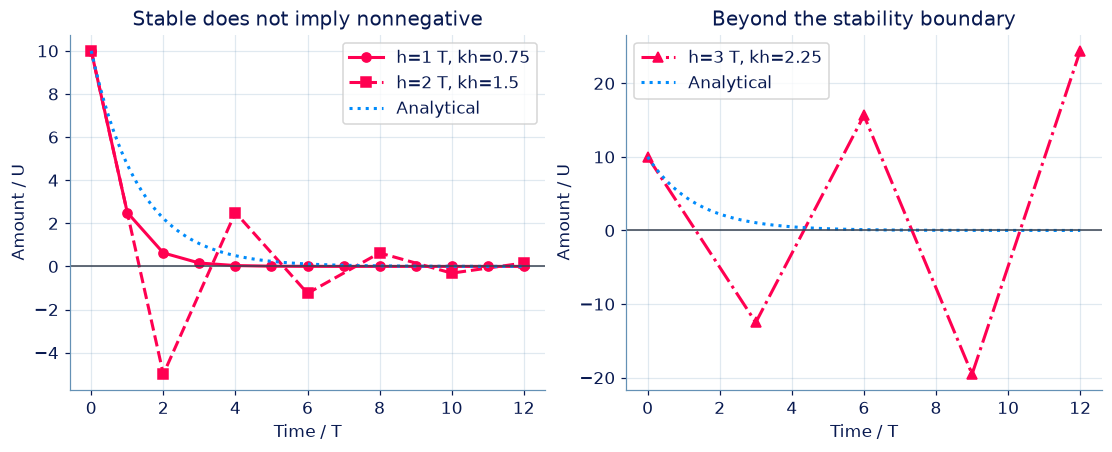

| h / T | q | 严格渐近稳定 | 非负保证 |
| --- | --- | --- | --- |
| 1 | 0.25 | 1 | 1 |
| 2 | -0.5 | 1 | 0 |
| 3 | -1.25 | 0 | 0 |

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for h,style in [(1,'o-'),(2,'s--'),(3,'^-.')]:
    values,_=euler(10,0,.75,h,round(12/h))
    ax=axes[0] if h<=2 else axes[1]
    ax.plot(np.arange(len(values))*h,values,style,color='#ff0051',label=f'h={h} T, kh={.75*h:g}')
t=np.linspace(0,12,201)
for ax in axes:
    ax.plot(t,exact_series(10,0,.75,t),color='#008bfb',ls=':',label='Analytical')
    ax.axhline(0,color='#384251',lw=1);ax.set(xlabel='Time / T',ylabel='Amount / U');ax.legend()
axes[0].set_title('Stable does not imply nonnegative');axes[1].set_title('Beyond the stability boundary')
plt.show()
display(Markdown(show_table(['h / T','q','严格渐近稳定','非负保证'],[(h,*step_properties(.75,h)) for h in [1,2,3]])))

## 结果解释

左图 h=2 T 的第一步为 −5 U，之后交替衰减；它是稳定而不保持非负的失败例。右图单独展示 kh>2 的增长振荡，避免大幅值压扁左图。两图坐标纵轴范围不同，比较的是各自行为而非视觉振幅大小。

### 独立核对

专门测试 kh=0、1、2 及两侧，防止把严格不等号写错。自动检查不会把失败曲线删除或裁成零。

In [5]:
assert first_decay(10,.75,[1,2])==[2.5,-5]
assert step_properties(.75,2)==(-.5,True,False)
assert step_properties(.5,4)==(-1,False,False)
assert step_properties(0,1)==(1,False,True)
assert step_properties(.5,2)==(0,True,True)
edge,_=euler(10,0,.5,4,4)
np.testing.assert_allclose(edge,[10,-10,10,-10,10])
print('稳定边界、非负边界、零清除和首步负值均符合推导。')

稳定边界、非负边界、零清除和首步负值均符合推导。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-04-数值模拟、误差与迁移/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：分别检查稳定与非负条件

本题只讨论恒定输入（input）一阶模型（model）的显式欧拉法（forward Euler method）更新。给定非负 k 和正 h，返回偏差放大因子 q，以及严格渐近稳定（asymptotic stability）、对所有非负初值（initial condition）与输入保持非负这两个布尔判断。

**函数与代码模板**

```python
def solve(
    k: float,
    h: float,
) -> tuple[float, bool, bool]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `h` | `float` | 时间步长（time step）。 | T |

**返回值**

按以下顺序返回元组：(q, stable, nonnegative)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `q` | `float` | 1−k*h。 | 1 |
| `stable` | `bool` | 是否 abs(q)<1；k=0 不属于严格渐近稳定。 | 1 |
| `nonnegative` | `bool` | 是否 q≥0；保证所有 A0≥0、u≥0 的下一步非负。 | 1 |

**计算规则**

q=1−kh；stable=(abs(q)<1)；nonnegative=(q>=0)。本题要求精确不等号，不加数值容差扩大边界。

**约束与边界**

- 所有数值有限；无需修改输入。
- 0 ≤ k ≤ 2；0 < h ≤ 4；测试数值包含 kh=0、1、2 及两侧。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| k | 清除系数（elimination rate constant）。 | 0.75 | 1/T |
| h | 时间步长（time step）。 | 2 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
k = 0.75
h = 2

result = solve(k, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| q | 1−k*h。 | -0.5 | 1 |
| stable | 是否 abs(q)<1；k=0 不属于严格渐近稳定。 | True | 1 |
| nonnegative | 是否 q≥0；保证所有 A0≥0、u≥0 的下一步非负。 | False | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (-0.5, True, False)
```

**样例解释**

kh=1.5，q=−0.5：偏差大小逐步减半，因此 stable=True；但可能出现负所追踪物质总量（tracked amount），nonnegative=False。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：分别检查稳定与非负条件](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-step-properties)

### 第 2 题 · Python 计算题：负值出现在第一步

无输入（input）时从 A0≥0 开始，对不同步长分别做一次欧拉法（forward Euler method）更新。返回每个步长得到的第一步所追踪物质总量（tracked amount），保留负值。

**函数与代码模板**

```python
def solve(
    A0: float,
    k: float,
    step_sizes: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 初始总量。 | U |
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `step_sizes` | `list[float]` | 分别尝试的步长。 | T |

**返回值**

直接返回 first（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `first` | `list[float]` | 各自第一步总量。 | U |

**计算规则**

每个试验独立从 A0 出发，返回 A0*(1−k*h)，不裁剪、不连续串接。

**约束与边界**

- 所有数值有限；无需修改输入。
- 0 ≤ A0 ≤ 20；0 ≤ k ≤ 2；0 < h ≤ 4；列表长度 1—100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 初始总量。 | 10 | U |
| k | 清除系数（elimination rate constant）。 | 0.75 | 1/T |
| step_sizes | 分别尝试的步长。 | [1, 2] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 10
k = 0.75
step_sizes = [1, 2]

result = solve(A0, k, step_sizes)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| first | 各自第一步总量。 | [2.5, -5.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.5, -5.0]
```

**样例解释**

h=1 时为 2.5 U；h=2 时为 −5 U。连续衰减在相同时刻都应为正，因此负值是算法失败信号。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：负值出现在第一步](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-first-decay)

### 第 3 题 · 多项选择题：稳定曲线也会不合理

无输入（input）清除中 kh=1.5、A0>0。偏差放大因子为 −0.5。哪些说法成立？

- **A.** 数值绝对值趋向零。
- **B.** 每一步必定非负。
- **C.** 曲线交替正负，与连续解的单调正衰减不同。
- **D.** 稳定意味着任何步长精度都足够好。

[作答：稳定曲线也会不合理](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-stable-not-positive)

### 第 4 题 · 单项选择题：边界 kh=2

无输入（input）、A0=10 U、kh=2。欧拉法（forward Euler method）轨迹（trajectory）是哪种行为？

- **A.** 10、−10、10、−10…，幅值不衰减，不是严格渐近稳定（asymptotic stability）。
- **B.** 10、0、0…，一步达到零。
- **C.** 始终为 10。
- **D.** 平滑指数衰减。

[作答：边界 kh=2](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-stability-boundary)

### 第 5 题 · 多项选择题：发现负值后的正确处理

数值曲线出现负所追踪物质总量（tracked amount），但方程在非负初值（initial condition）和输入（input）下保持非负。哪些操作有助于查明原因？

- **A.** 保留失败轨迹（trajectory），减小步长并对照解析解（analytical solution）。
- **B.** 检查 kh 与实际步长。
- **C.** 直接隐藏负值，继续称原算法通过。
- **D.** 把模型（model）参数（parameter）改到没有负值，但不说明改变了问题。

[作答：发现负值后的正确处理](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-do-not-clip)

**进一步阅读**

[MIT 一阶微分方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/)：Euler 方法与解曲线；本节稳定与非负条件由上述标量递推直接推导。